In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## Exercise 01.1

### Radius mean value


Below are reported the calculations of radius and variance obtained using $10^6$ step divided in 100 blocks


Here the implementation of the mean radius calculation and it's error:

```C++

vector<double> ave (N, 0); //averages on blocks
vector<double> av2 (N, 0); //averages squared on blocks

vector<double> sum_prog (N, 0);
vector<double> su2_prog (N, 0);
vector<double> err_prog (N, 0);

for(int i=0; i<N; ++i) //iterate on blocks
{
    float sum1=0; 
    for(int j=0; j<L; ++j) //iterate inside block
    {
        //generate along uniform distribution
        float r=rnd.Rannyu();
        sum1+=r;	      
    }
    ave[i] = sum1/L; //average on block
    av2[i]=pow(ave[i], 2); 		
}

for(int i=0; i<N; ++i)
{
    for(int j=0; j<=i; ++j)
    {
        sum_prog[i]+=ave[j]; // sum j=0,i r_j
        su2_prog[i]+=av2[j]; // sum j=0,i (r_j)^2
    }

    sum_prog[i]/=(i+1);
    su2_prog[i]/=(i+1);
    err_prog[i] = error(sum_prog, su2_prog, i);
}


```

data_M1000000.csv


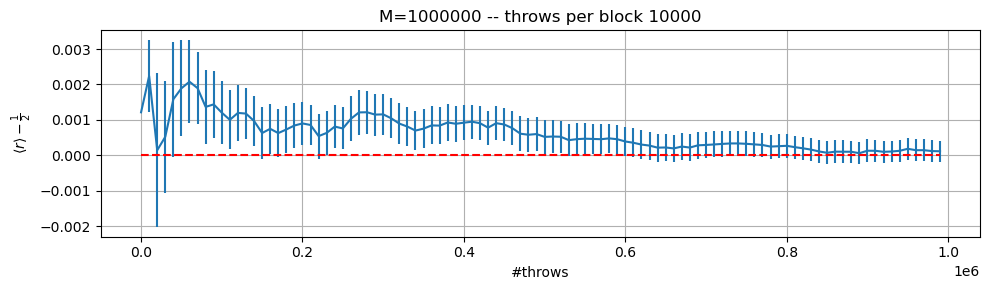

In [10]:
fig, ax = plt.subplots(1, 1,figsize=(10, 3))
n=0
for el in (os.listdir('data')):
    if ('data' not in el):
        continue
    if ('.csv'  not in el) or ('M' not in el):
        continue
    print(el)
    M=int(el.split('M')[1].split('.')[0])
        
    df=pd.read_csv('data/'+el)
    ax.set_title(f'M={M} -- throws per block {M//100}')
    
    ax.errorbar(
        df.throws, df.avg-0.5,
        yerr=df.err, 
        #c='r', ecolor='b'
    )

    # expected value
    ax.hlines(0, 0, df.throws[len(df)-1]+1, ls='--', colors='r')
    ax.set_xlabel('#throws')
    ax.set_ylabel(r'$\langle r \rangle-\frac{1}{2}$')
    ax.grid(True)
    n+=1
plt.tight_layout()
plt.show()

### Variance 

var_estimation_M1000000.csv


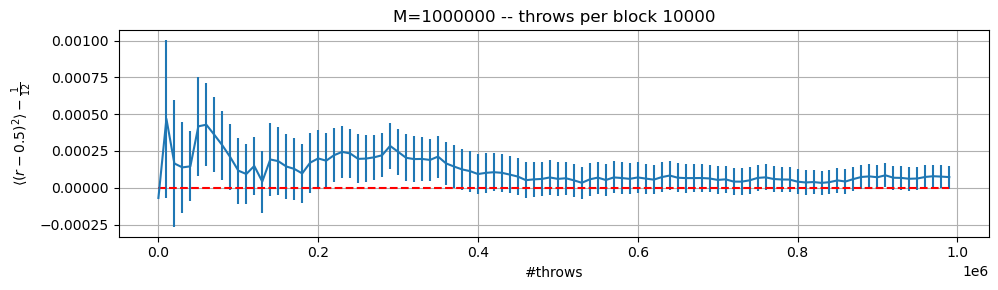

In [16]:
fig, ax = plt.subplots(1, 1,figsize=(10, 3))
n=0
for el in (os.listdir('data')):
    if ('var_estimation' not in el):
        continue
    if ('.csv'  not in el) or ('M' not in el):
        continue
    print(el)
    M=int(el.split('M')[1].split('.')[0])
        
    df=pd.read_csv('data/'+el)
    ax.set_title(f'M={M} -- throws per block {M//100}')
    
    ax.errorbar(
        df.throws, df.avg-1/12,
        yerr=df.err, 
        #c='r', ecolor='b'
    )

    # expected value
    ax.hlines(0, 0, df.throws[len(df)-1]+1, ls='--', colors='r')
    ax.set_xlabel('#throws')
    ax.set_ylabel(r'$\langle (r-0.5)^2 \rangle-\frac{1}{12}$')
    ax.grid(True)
    n+=1
plt.tight_layout()
plt.show()

both the radius and the variance converge at a value whom distance from the actual value is less than one standard deviation

# Chi 2

In [37]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [41]:
df=pd.read_csv('data/chi2.csv')


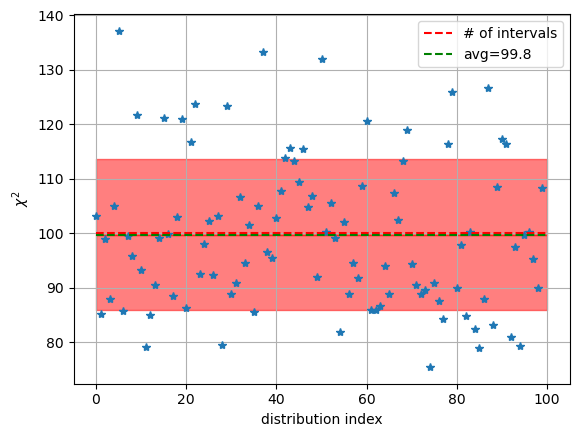

In [71]:

plt.plot(df.data, '*')
plt.hlines(
    100, 0, len(df),
    ls='--', colors='r', 
    label='# of intervals'
)

plt.hlines(
    df.data.mean(), 0, len(df), 
    ls='--', colors='g', 
    label=f'avg={"%.1f"%df.data.mean()}'
)

plt.fill_between(
    range(0,101), 
    df.data.mean(), 
    df.data.mean()+np.sqrt(df.data.var()),
    color='r', alpha=0.5
)
plt.fill_between(
    range(0,101), 
    df.data.mean(), 
    df.data.mean()-np.sqrt(df.data.var()),
    color='r', alpha=0.5
)


plt.ylabel(r'$\chi^2$')
plt.xlabel('distribution index')
plt.grid(True)
plt.legend()
plt.show()

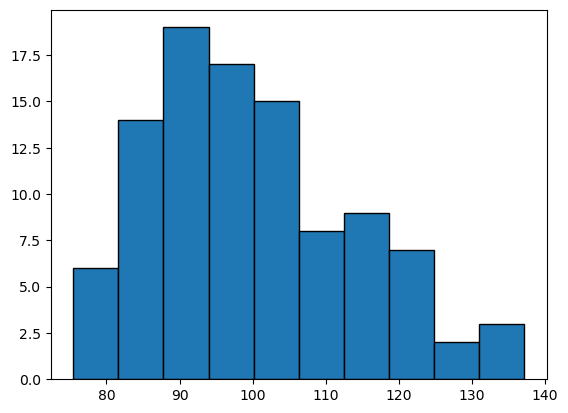

In [84]:
plt.hist(df.data, edgecolor='black', linewidth=1)
#lt.hlines(100, 0, len(df), ls='--', colors='r')

#$plt.ylabel(r'$\chi^2$')
#plt.xlabel('distribution index')
#plt.grid(True)
plt.show()

## Exercise 01.2

da capire se implementato correttamente: io lancio il 'dado' $10^4$ volte ma poi il numero di elementi che genero dipende dal pedice della somma infatti per $S_100$ ho 100 elementi perche ne uso 100 dei $10^4$ per generare la singola somma

In [47]:
from scipy.optimize import curve_fit
import numpy as np

def gaussian(x, mu, sigma):
    return np.exp(-pow(x-mu, 2)/(2*sigma**2))/(np.sqrt(2*np.pi)*sigma)

## Exponential distribution

In [53]:
N1=pd.read_csv('data/exp_N1.csv')
N2=pd.read_csv('data/exp_N2.csv')
N10=pd.read_csv('data/exp_N10.csv')
N100=pd.read_csv('data/exp_N100.csv')


In [60]:
N100

,data
0,0.991960
1,1.051740
2,1.007820
3,0.987448
4,0.960612
...,...
95,1.050500
96,1.009300
97,0.975320
98,0.896127


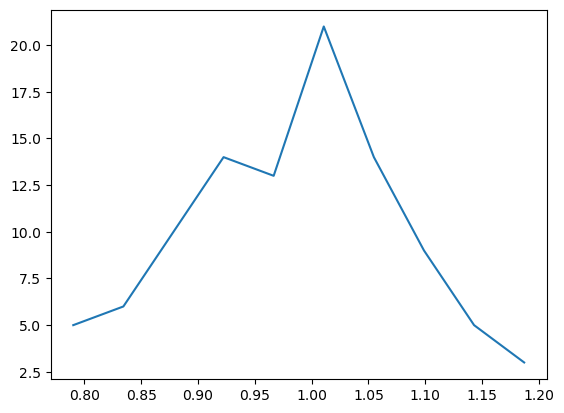

In [69]:
y, bins = np.histogram(N100.data)
xc=[0.5*(bins[k]+bins[k+1]) for k in range(len(bins)-1)]


plt.plot(xc, y)

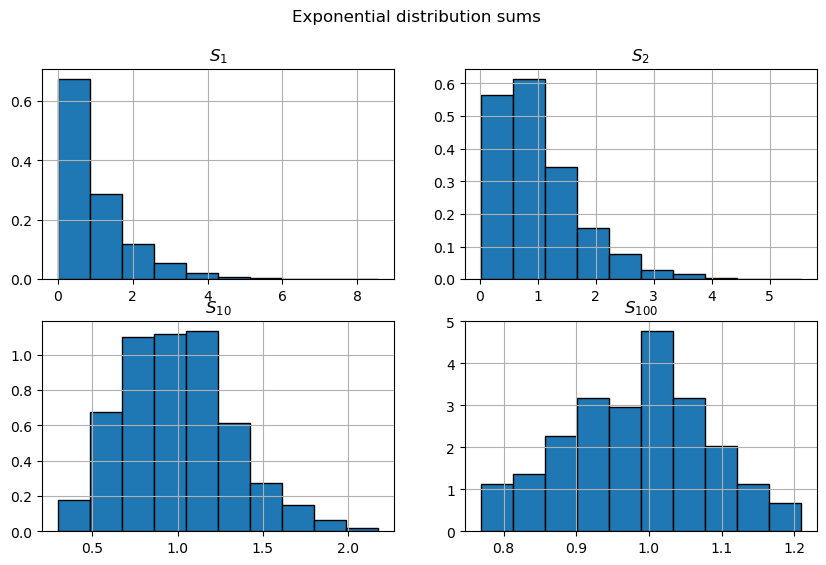

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,6))
fig.suptitle('Exponential distribution sums')


ax[0, 0].hist(N1.data, label='1', density=True, edgecolor='black', linewidth=1)
ax[0, 0].set_title('$S_1$')

ax[0, 1].hist(N2.data, label='2', density=True, edgecolor='black', linewidth=1)
ax[0, 1].set_title('$S_2$')

ax[1, 0].hist(N10.data, label='10', density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_title('$S_{10}$')

ax[1, 1].hist(N100.data, label='100', density=True, edgecolor='black', linewidth=1)
ax[1, 1].set_title('$S_{100}$')

popt, pcov = curve_fit(gaussian, )

for k in [0,1]:
    for j  in [0,1]:
        ax[k,j].grid(True)
plt.show()

## Uniform distribution

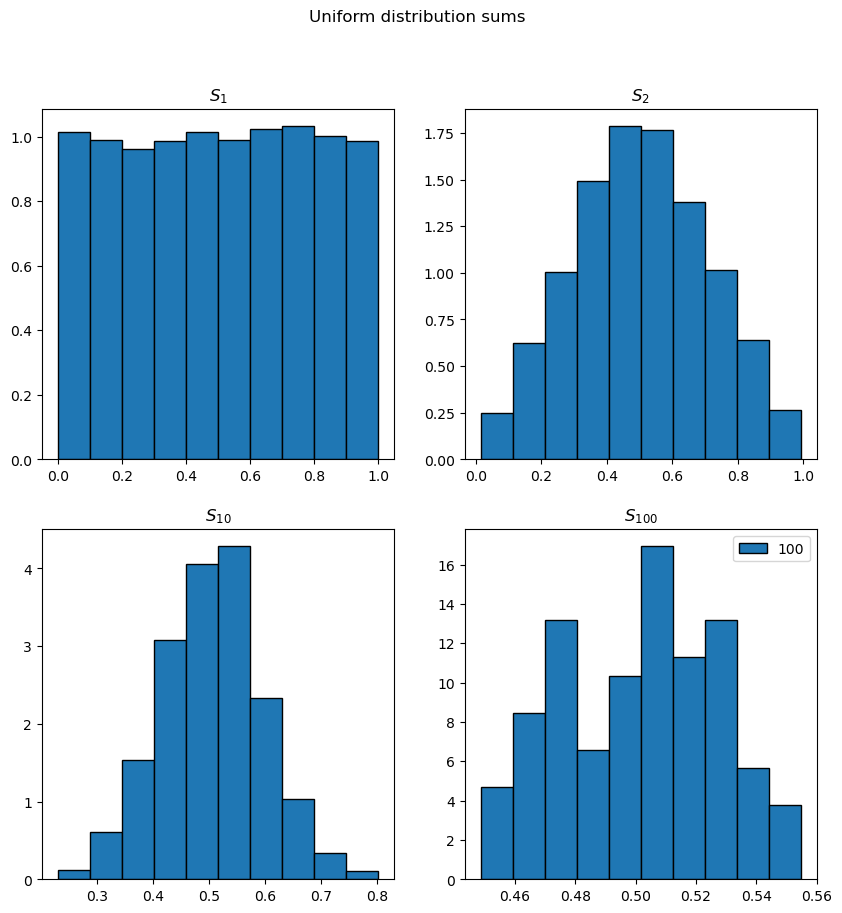

In [27]:
N1=pd.read_csv('data/unif_N1.csv')
N2=pd.read_csv('data/unif_N2.csv')
N10=pd.read_csv('data/unif_N10.csv')
N100=pd.read_csv('data/unif_N100.csv')

fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle('Uniform distribution sums')


ax[0, 0].hist(N1.data, label='1', density=True, edgecolor='black', linewidth=1)
ax[0, 0].set_title('$S_1$')

ax[0, 1].hist(N2.data, label='2', density=True, edgecolor='black', linewidth=1)
ax[0, 1].set_title('$S_2$')

ax[1, 0].hist(N10.data, label='10', density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_title('$S_{10}$')

ax[1, 1].hist(N100.data, label='100', density=True, edgecolor='black', linewidth=1)
ax[1, 1].set_title('$S_{100}$')

plt.legend()
plt.show()

## Cauchy-Lorentz

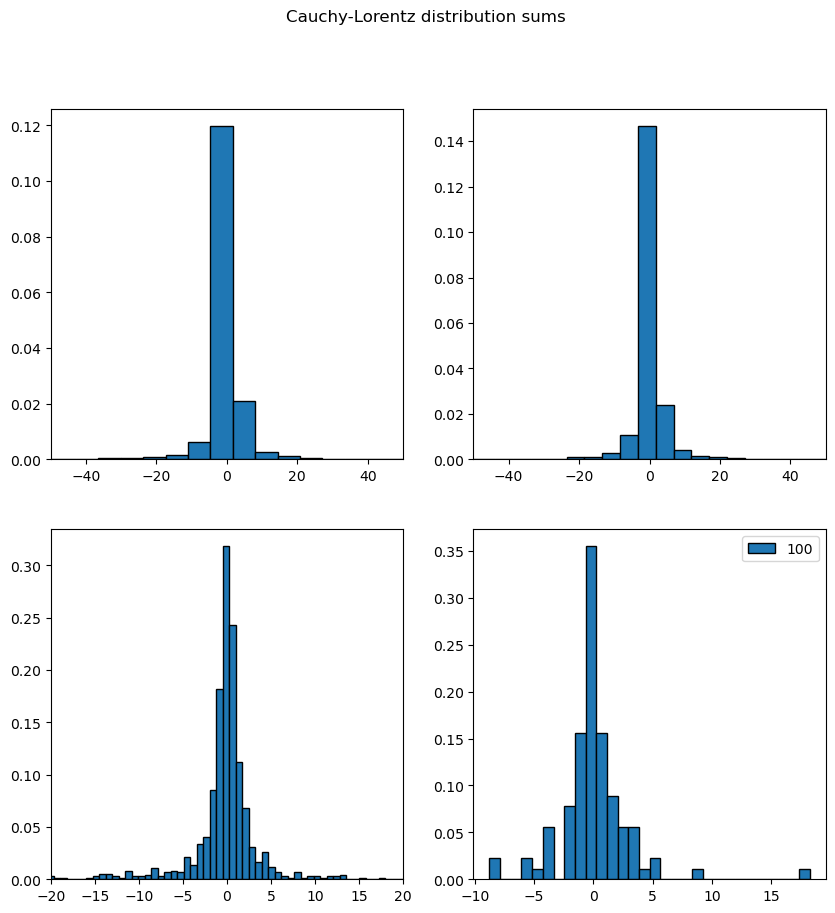

In [40]:
N1=pd.read_csv('data/cauchy_N1.csv')
N2=pd.read_csv('data/cauchy_N2.csv')
N10=pd.read_csv('data/cauchy_N10.csv')
N100=pd.read_csv('data/cauchy_N100.csv')


fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle('Cauchy-Lorentz distribution sums')


ax[0, 0].hist(N1.data,   label='1', bins=3000, density=True, edgecolor='black', linewidth=1)
ax[0,0].set_xlim([-50, 50])

ax[0, 1].hist(N2.data,   label='2', bins=3000, density=True, edgecolor='black', linewidth=1)
ax[0,1].set_xlim([-50, 50])

ax[1, 0].hist(N10.data,  label='10', bins=300,  density=True, edgecolor='black', linewidth=1)
ax[1, 0].set_xlim([-20, 20])

ax[1, 1].hist(N100.data, label='100', bins=30, density=True, edgecolor='black', linewidth=1)

plt.legend()
plt.show()

(-20.0, 20.0)

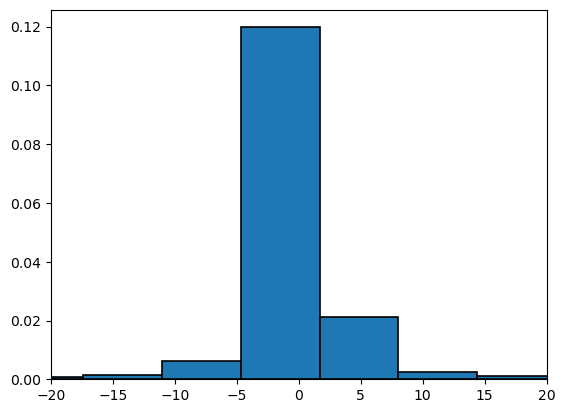

In [96]:
plt.hist(N1.data, bins=3000, label='1', density=True, linewidth=1.2, edgecolor='black')
plt.xlim([-20., 20])


dire qualcosa sul fatto che cauchy ha media e varianza non def quindi no clt|

### Exercise 01.3

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
bf = pd.read_csv('data/prob_buffon.csv')

bf

,throws,avg,err
0,0,2.96296,0.000000
1,100,3.08148,0.118519
2,200,3.00670,0.101362
3,300,2.95678,0.087345
4,400,3.07654,0.137546
...,...,...,...
95,9500,3.15988,0.038836
96,9600,3.15785,0.038487
97,9700,3.15113,0.038679
98,9800,3.15369,0.038372


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4495/2531555135.py:2: SyntaxWarning: invalid escape sequence '\p'
  plt.title('$\pi$ estimation')
/tmp/ipykernel_4495/2531555135.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\pi$')


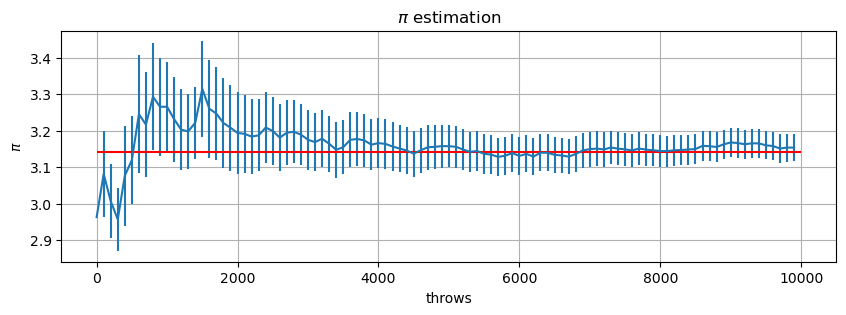

In [31]:
plt.figure(figsize=(10,3))
plt.title('$\pi$ estimation')
plt.errorbar(bf.throws, bf.avg, yerr=bf.err)
plt.hlines(np.pi, 0, 10000, color='r')
plt.grid()
plt.ylabel('$\pi$')
plt.xlabel('throws')

plt.show()